# Analysis of the bilayer lipid simulation

In [10]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

## Fluctuations of pressure and temperature

In [14]:
data = np.loadtxt("pressure_and_temperature.xvg", comments=["@", "#"])

time = []
temperature = []
pressure = []

for row in data:
    time.append(row[0])
    temperature.append(row[1])
    pressure.append(row[2])

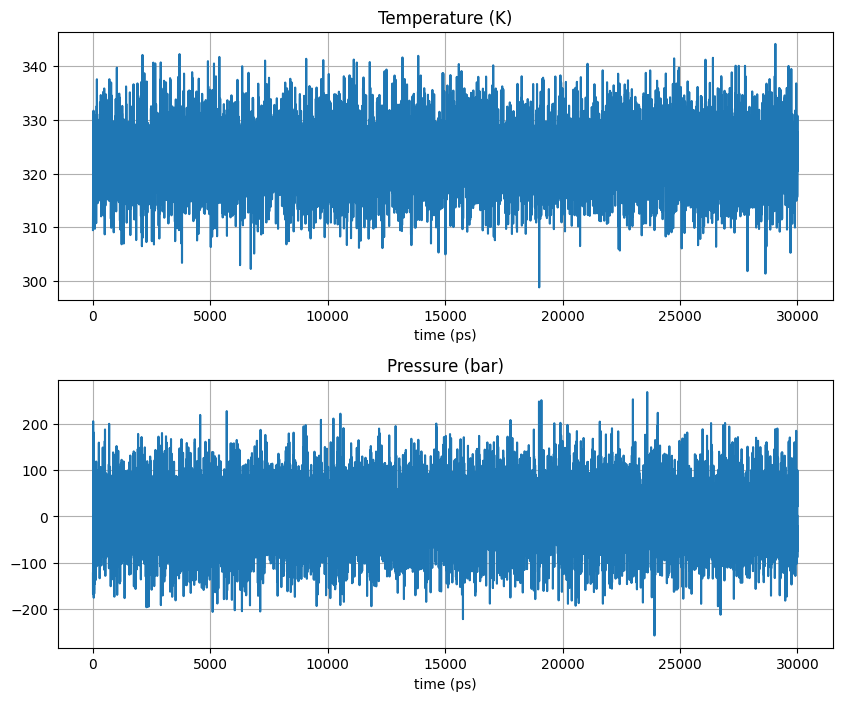

In [15]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 8))


ax = axs[0]
ax.plot(time, temperature)
ax.set_title("Temperature (K)")
ax.set_xlabel("time (ps)")
ax.grid()

ax = axs[1]
ax.plot(time, pressure)
ax.set_title("Pressure (bar)")
ax.set_xlabel("time (ps)")
ax.grid()

plt.subplots_adjust(hspace = 0.3)

In [16]:
ntransient = 1000
time_nt = time[ntransient:]
temperature_nt = temperature[ntransient:]
pressure_nt = pressure[ntransient:]


print("Fluctuation std:")
print("Temperature:", np.std(temperature_nt), " K")
print("Pressure: ", np.std(pressure_nt), " bar")

Fluctuation std:
Temperature: 5.850089461184297  K
Pressure:  68.25545231563304  bar


Pressure fluctuations are huge. Controlling pressure in a simulation is very hard, much harder than controlling temperature.

# Area per lipid

Careful because the box dimension does not stay fixed through the simulation. 

Indeed, we are running a simulation at constant temperature (-> energy changes) and pressure (-> volume changes) (**Gibbs ensemble**)!

In [17]:
# Naif calculaation:

box_area = 7.5**2

area_per_lipid =  box_area / 64

area_per_lipid

# Taking into account the right average box area through the simulation:

0.87890625

In [19]:
data = np.loadtxt("box_dimensions.xvg", comments=["@", "#"])


time = []
x = []
y = []
z = []

for step in data:
    time.append(step[0])
    x.append(step[1])
    y.append(step[2])
    z.append(step[3])

In [20]:
print(np.mean(x), np.mean(y), np.mean(z))

7.483101603439656 7.483101603439656 5.61431197440256


In [21]:
true_mean_yz_area = np.mean(y)*np.mean(z)

true_area_per_lipid = true_mean_yz_area / 64
print(true_area_per_lipid)

0.6564447959040978


## Thickness

In [7]:
data = np.loadtxt("density-P.xvg", comments=["@", "#"])

xvals = []
rhovals = []
for p in data:
    xvals.append(p[0])
    rhovals.append(p[1])

Thickness: 4.6395  nm


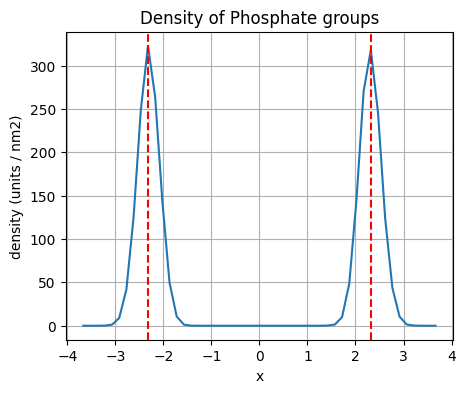

In [16]:
idxs = np.argsort(rhovals)[::-1]



fig, ax = plt.subplots(figsize = (5,4))
ax.plot(xvals, rhovals)
ax.axvline(xvals[idxs[0]], ls = "--", color = "red")
ax.axvline(xvals[idxs[1]], ls = "--", color = "red")
ax.set_xlabel("x")
ax.set_ylabel("density (units / nm2)")
ax.set_title("Density of Phosphate groups")
ax.grid()

print("Thickness:", xvals[idxs[1]]- xvals[idxs[0]], " nm")

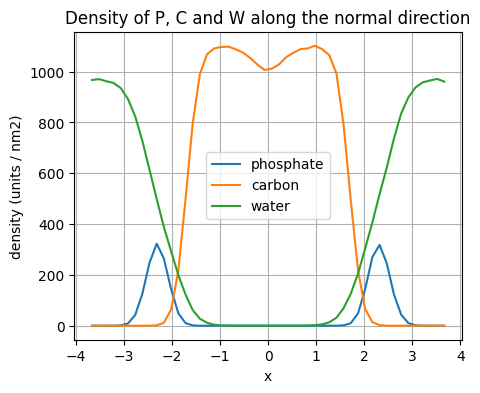

In [17]:
files = ["density-P.xvg", "density-C.xvg", "density-W.xvg"]
labels = ["phosphate", "carbon", "water"]


fig, ax = plt.subplots(figsize = (5,4))

for i, f in enumerate(files):

    data = np.loadtxt(f, comments=["@", "#"])
    xvals = []
    rhovals = []
    for p in data:
        xvals.append(p[0])
        rhovals.append(p[1])

    
    ax.plot(xvals, rhovals, label = labels[i])
    ax.set_xlabel("x")
    ax.set_ylabel("density (units / nm2)")
    ax.set_title("Density of P, C and W along the normal direction")
    ax.grid()

ax.legend()

## Order Parameter

In [2]:
import pandas as pd

In [8]:
colnames = ["Frame", "NC3-PO4", "PO4-GL1", "GL1-GL2", "GL1-C1A", "GL2-C1B",
            "C1A-C2A", "C2A-C3A", "C3A-C4A", "C4A-C5A",
            "C1B-C2B", "C2B-C3B", "C3B-C4B", "C4B-C5B"]

df = pd.read_csv("order.dat", skiprows=1, sep = "  ", names=colnames)

df = df[0:101]

df

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_25971/3947361941.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv("order.dat", skiprows=1, sep = "  ", names=colnames)


,Frame,NC3-PO4,PO4-GL1,GL1-GL2,GL1-C1A,GL2-C1B,C1A-C2A,C2A-C3A,C3A-C4A,C4A-C5A,C1B-C2B,C2B-C3B,C3B-C4B,C4B-C5B
0,0,-0.009,0.006,-0.037,0.027,-0.015,0.033,0.035,0.061,0.048,0.009,-0.006,0.017,0.005
1,1,-0.037,0.004,-0.002,0.023,-0.007,0.107,0.062,-0.006,-0.035,0.031,-0.026,0.015,0.041
2,2,-0.006,0.044,-0.069,0.070,0.069,0.039,0.093,0.040,0.102,0.001,-0.021,0.009,0.044
3,3,-0.033,0.100,-0.044,0.118,0.004,0.100,-0.037,0.004,0.054,-0.003,0.000,0.061,-0.035
4,4,-0.024,0.035,0.012,0.018,0.035,0.034,0.014,-0.025,0.034,0.018,-0.048,0.005,-0.055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,-0.134,0.573,-0.175,0.483,0.425,0.483,0.335,0.301,0.216,0.452,0.410,0.223,0.087
97,97,-0.149,0.566,-0.205,0.511,0.405,0.483,0.419,0.282,0.223,0.488,0.424,0.301,0.181
98,98,-0.080,0.525,-0.175,0.493,0.436,0.482,0.418,0.280,0.244,0.436,0.375,0.277,0.106
99,99,-0.114,0.600,-0.190,0.505,0.459,0.497,0.387,0.198,0.166,0.419,0.412,0.354,0.115


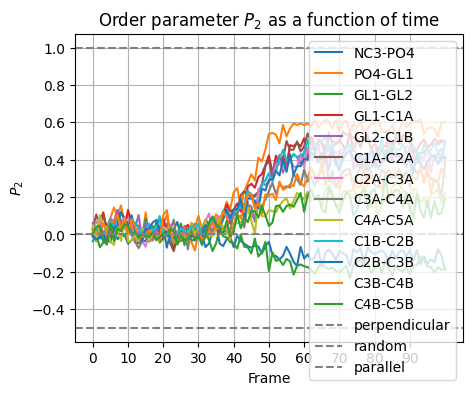

In [27]:
fig, ax = plt.subplots(figsize = (5,4))

cols_to_plot = ["NC3-PO4", "PO4-GL1", ]

for col in df.columns[1:]: 
    ax.plot(df["Frame"], df[col], label=col)

ax.set_xticks(np.arange(0, 100, 10))
ax.set_xticklabels(np.arange(0, 100, 10))
ax.set_xlabel("Frame")
ax.set_ylabel(r"$P_2$")
ax.set_title(r"Order parameter $P_2$ as a function of time")


ax.axhline(y = -0.5, color = "grey", ls = "--", label = "perpendicular")
ax.axhline(y = +0, color = "grey", ls = "--", label = "random")
ax.axhline(y = +1, color = "grey", ls = "--", label = "parallel")

ax.legend()
ax.grid()
plt.show()